
# DS 352 II (Exploratory Work)
**Tools:** Python, Pandas, NumPy, Matplotlib


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

DATA_PATH = "usda_branded_with_nutrition_per_serving (1).csv"  # adjust if needed



Ready. Will load from: usda_branded_with_nutrition_per_serving (1).csv


## 1) Load dataset

In [4]:

df = pd.read_csv(DATA_PATH, low_memory=False)
print("Shape:", df.shape)
df.head(10)


Shape: (1048575, 15)


,company_brand,product,branded_food_category,serving_size,serving_size_unit,calories_per_serving,protein_g_per_serving,carbs_g_per_serving,fat_g_per_serving,fiber_g_per_serving,sodium_mg_per_serving,cholesterol_mg_per_serving,satfat_g_per_serving,iron_mg_per_serving,potassium_mg_per_serving
0,Richardson Oilseed Products (US) Limited,WESSON Vegetable Oil 1 GAL,Oils Edible,15.0,ml,130.05,0.0000,0.0000,13.9995,0.000,0.00,0.00,1.9995,0.0000,0.00
1,CAMPBELL SOUP COMPANY,SWANSON BROTH BEEF,Herbs/Spices/Extracts,240.0,ml,9.60,1.9920,1.0080,0.0000,0.000,830.40,0.00,0.0000,0.0000,0.00
2,CAMPBELL SOUP COMPANY,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,Prepared Soups,440.0,g,360.80,10.7800,26.9280,23.3640,1.760,1597.20,26.40,4.4880,1.0560,286.00
3,CAMPBELL SOUP COMPANY,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,Prepared Soups,440.0,g,360.80,5.3680,23.3640,26.9280,1.760,1416.80,44.00,10.7800,0.7040,286.00
4,CAMPBELL SOUP COMPANY,SWANSON BROTH CHICKEN,Herbs/Spices/Extracts,240.0,ml,9.60,1.9920,1.0080,0.0000,0.000,36.00,0.00,0.0000,0.0000,28.80
5,CAMPBELL SOUP COMPANY,CAMPBELL'S SOUP BEAN AND HAM,Prepared Soups,412.0,g,251.32,15.1204,43.7132,2.5132,9.888,1260.72,16.48,0.0000,3.3784,638.60
6,CAMPBELL SOUP COMPANY,SWANSON BROTH BEEF,Herbs/Spices/Extracts,411.0,g,16.44,3.4935,1.7673,0.0000,0.000,1450.83,0.00,0.0000,0.3699,53.43
7,CAMPBELL SOUP COMPANY,PREGO SAUCES TOMATO BASIL,Sauces/Spreads/Dips/Condiments,120.0,ml,69.60,2.0040,6.9960,3.9960,3.000,429.60,0.00,0.5040,0.3600,210.00
8,CAMPBELL SOUP COMPANY,CAMPBELL'S SOUP TOMATO,Prepared Soups,120.0,ml,90.00,2.0040,18.0000,1.5000,0.960,410.40,0.00,0.0000,0.3960,620.40
9,CAMPBELL SOUP COMPANY,CAMPBELL'S PASTA SPAGHETTIOS W FRANKS,Dough Based Products / Meals,443.0,g,385.41,15.8151,50.9893,12.3154,5.316,1054.34,44.30,3.4997,2.7909,651.21


## 2) Choose nutrient columns & coerce numeric

In [ ]:

ALL_NUTRIENTS = [
    "calories_per_serving",
    "protein_g_per_serving",
    "carbs_g_per_serving",
    "fat_g_per_serving",
    "fiber_g_per_serving",
    "sodium_mg_per_serving",
    "cholesterol_mg_per_serving",
    "satfat_g_per_serving",
    "iron_mg_per_serving",
    "potassium_mg_per_serving"
]

present_all = [c for c in ALL_NUTRIENTS if c in df.columns]
missing = [c for c in ALL_NUTRIENTS if c not in df.columns]
if missing:
    print("Missing expected nutrient columns (will skip):", missing)

# Coerce just the present nutrients to numeric (leave others intact)
for c in present_all:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Nutrient columns used:", present_all)
df[present_all].head(5)


Nutrient columns used: ['calories_per_serving', 'protein_g_per_serving', 'carbs_g_per_serving', 'fat_g_per_serving', 'fiber_g_per_serving', 'sodium_mg_per_serving', 'cholesterol_mg_per_serving', 'satfat_g_per_serving', 'iron_mg_per_serving', 'potassium_mg_per_serving']


,calories_per_serving,protein_g_per_serving,carbs_g_per_serving,fat_g_per_serving,fiber_g_per_serving,sodium_mg_per_serving,cholesterol_mg_per_serving,satfat_g_per_serving,iron_mg_per_serving,potassium_mg_per_serving
0,130.05,0.000,0.000,13.9995,0.00,0.0,0.0,1.9995,0.000,0.0
1,9.60,1.992,1.008,0.0000,0.00,830.4,0.0,0.0000,0.000,0.0
2,360.80,10.780,26.928,23.3640,1.76,1597.2,26.4,4.4880,1.056,286.0
3,360.80,5.368,23.364,26.9280,1.76,1416.8,44.0,10.7800,0.704,286.0
4,9.60,1.992,1.008,0.0000,0.00,36.0,0.0,0.0000,0.000,28.8


## 3) Summary stats (before outlier handling) — all nutrients

In [6]:

summary_before = df[present_all].describe(percentiles=[.05,.25,.5,.75,.95]).T.round(3)
summary_before


,count,mean,std,min,5%,25%,50%,75%,95%,max
calories_per_serving,1026383.0,136.038,238.216,0.0,4.6,60.00,120.000,170.100,309.550,1.857042e+04
protein_g_per_serving,1044521.0,4.486,13.156,0.0,0.0,0.00,2.000,6.000,15.999,9.000180e+02
carbs_g_per_serving,1037363.0,18.168,40.539,0.0,0.0,4.00,15.997,25.001,43.003,7.325007e+03
fat_g_per_serving,1022425.0,5.489,9.188,0.0,0.0,0.00,3.000,8.999,17.000,9.000000e+02
fiber_g_per_serving,854175.0,1.530,3.191,0.0,0.0,0.00,1.000,2.010,5.002,3.301200e+02
sodium_mg_per_serving,1030817.0,402.362,9355.735,0.0,0.0,24.80,119.850,280.000,709.710,1.460001e+06
cholesterol_mg_per_serving,854045.0,33.310,1104.374,0.0,0.0,0.00,0.000,15.300,60.060,2.349991e+05
satfat_g_per_serving,883063.0,2.279,4.176,0.0,0.0,0.00,1.001,3.500,8.000,9.000000e+02
iron_mg_per_serving,830924.0,2.344,353.133,0.0,0.0,0.00,0.701,1.085,2.706,3.000000e+05
potassium_mg_per_serving,363312.0,6186.698,3484018.868,0.0,0.0,43.95,122.400,239.970,480.000,2.100000e+09


## 4) Identify & handle outliers — IQR winsorization (k higher) on all nutrients

In [ ]:
# Winsorization using IQR method
IQR_K = 6
def winsorize_iqr(series, k=6):
    s = series.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - k*iqr
    upper = q3 + k*iqr
    return series.clip(lower, upper)

print(f"Applying IQR winsorization per nutrient (k={IQR_K}).")
df_w = df.copy()
for c in present_all:
    df_w[c] = winsorize_iqr(df[c], k=IQR_K)

summary_after = df_w[present_all].describe(percentiles=[.05,.25,.5,.75,.95]).T.round(3)
print("=== Summary AFTER winsorization (k={}) ===".format(IQR_K))
summary_after


Applying IQR winsorization per nutrient (k=6).
=== Summary AFTER winsorization (k=6) ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
calories_per_serving,1026383.0,129.260,99.995,0.0,4.6,60.00,120.000,170.100,309.550,830.700
protein_g_per_serving,1044521.0,4.204,5.594,0.0,0.0,0.00,2.000,6.000,15.999,42.001
carbs_g_per_serving,1037363.0,17.076,15.712,0.0,0.0,4.00,15.997,25.001,43.003,151.008
fat_g_per_serving,1022425.0,5.363,6.545,0.0,0.0,0.00,3.000,8.999,17.000,62.991
fiber_g_per_serving,854175.0,1.473,1.905,0.0,0.0,0.00,1.000,2.010,5.002,14.070
sodium_mg_per_serving,1030817.0,201.936,254.017,0.0,0.0,24.80,119.850,280.000,709.710,1811.200
cholesterol_mg_per_serving,854045.0,12.076,21.831,0.0,0.0,0.00,0.000,15.300,60.060,107.100
satfat_g_per_serving,883063.0,2.237,2.985,0.0,0.0,0.00,1.001,3.500,8.000,24.497
iron_mg_per_serving,830924.0,0.892,1.161,0.0,0.0,0.00,0.701,1.085,2.706,7.594
potassium_mg_per_serving,363312.0,171.051,183.613,0.0,0.0,43.95,122.400,239.970,480.000,1416.090


## 5) Missingness of data (bar chart) — all nutrients

potassium_mg_per_serving      0.654
iron_mg_per_serving           0.208
cholesterol_mg_per_serving    0.186
fiber_g_per_serving           0.185
satfat_g_per_serving          0.158
fat_g_per_serving             0.025
calories_per_serving          0.021
sodium_mg_per_serving         0.017
carbs_g_per_serving           0.011
protein_g_per_serving         0.004
dtype: float64


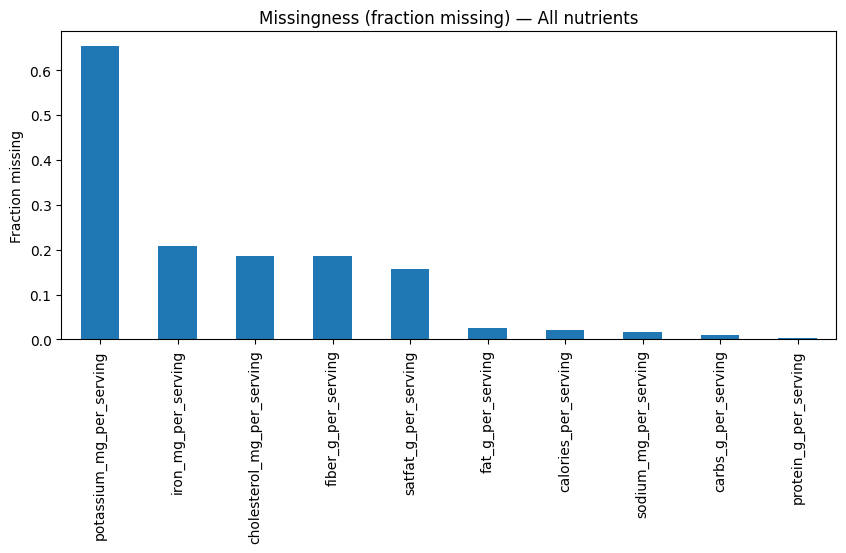

In [14]:

miss = df_w[present_all].isna().mean().sort_values(ascending=False)
print(miss.round(3))
ax = miss.plot(kind="bar", figsize=(10,4))
plt.title("Missingness (fraction missing) — All nutrients")
plt.ylabel("Fraction missing")
plt.show()


## 6) Binarization of low/high values — all nutrients

In [15]:

bin_counts = {}
for c in present_all:
    s = df_w[c]
    try:
        df_w[c+"_bin"] = pd.qcut(s, q=2, labels=["low","high"], duplicates="drop")
        # ensure both bins exist; otherwise fallback to median split
        if df_w[c+"_bin"].nunique(dropna=True) < 2:
            raise ValueError("Insufficient unique values for qcut; median fallback.")
    except Exception:
        med = s.median()
        df_w[c+"_bin"] = np.where(s <= med, "low", "high")
    bin_counts[c+"_bin"] = df_w[c+"_bin"].value_counts(dropna=False)

print("Bin counts per nutrient (low/high):")
for k, v in bin_counts.items():
    print(f"\n{k}\n{v}")


Bin counts per nutrient (low/high):

calories_per_serving_bin
calories_per_serving_bin
low     534282
high    492101
NaN      22192
Name: count, dtype: int64

protein_g_per_serving_bin
protein_g_per_serving_bin
low     523178
high    521343
NaN       4054
Name: count, dtype: int64

carbs_g_per_serving_bin
carbs_g_per_serving_bin
low     519348
high    518015
NaN      11212
Name: count, dtype: int64

fat_g_per_serving_bin
fat_g_per_serving_bin
low     514982
high    507443
NaN      26150
Name: count, dtype: int64

fiber_g_per_serving_bin
fiber_g_per_serving_bin
low     438452
high    415723
NaN     194400
Name: count, dtype: int64

sodium_mg_per_serving_bin
sodium_mg_per_serving_bin
low     515524
high    515293
NaN      17758
Name: count, dtype: int64

cholesterol_mg_per_serving_bin
cholesterol_mg_per_serving_bin
high    556184
low     492391
Name: count, dtype: int64

satfat_g_per_serving_bin
satfat_g_per_serving_bin
low     441659
high    441404
NaN     165512
Name: count, dtype: int

## 7) Category summary by **median** of all nutrients

In [22]:

cat_col = None
for cand in ["branded_food_category", "category_family", "category", "food_category"]:
    if cand in df_w.columns:
        cat_col = cand
        break

if cat_col is None:
    print("No category column found among: branded_food_category, category_family, category, food_category")
else:
    med_spec = {f"{c}_med": (c, "median") for c in present_all}
    first_present = present_all[0]
    cat_summary = df_w.groupby(cat_col).agg(n=(first_present, "count"), **med_spec).sort_values("n", ascending=False)
    print(f"Category column used: {cat_col}")


cat_summary.head(10)

Category column used: branded_food_category


,n,calories_per_serving_med,protein_g_per_serving_med,carbs_g_per_serving_med,fat_g_per_serving_med,fiber_g_per_serving_med,sodium_mg_per_serving_med,cholesterol_mg_per_serving_med,satfat_g_per_serving_med,iron_mg_per_serving_med,potassium_mg_per_serving_med
branded_food_category,,,,,,,,,,,
"Popcorn, Peanuts, Seeds & Related Snacks",50901,162.960,4.0012,12.0008,12.0008,2.001,80.10,0.00,1.9992,0.8990,160.05
Candy,50043,120.000,0.0000,24.0000,0.0000,0.000,15.12,0.00,0.0000,0.0000,2.10
Cheese,42238,90.000,6.0004,0.9996,7.0000,0.000,180.04,20.34,4.4990,0.0000,19.88
Ice Cream & Frozen Yogurt,33191,160.190,3.0000,22.0000,7.9992,0.000,59.84,24.70,4.9966,0.0000,149.65
Cookies & Biscuits,29513,140.100,1.0013,20.0013,6.0002,0.990,90.06,0.00,2.5008,0.7196,30.00
"Chips, Pretzels & Snacks",27519,140.049,1.9992,16.9988,7.9996,1.008,180.00,0.00,0.9996,0.3612,260.12
"Pickles, Olives, Peppers & Relishes",25266,19.950,0.0000,1.0005,0.0000,0.990,229.96,0.00,0.0000,0.1008,19.95
Breads & Buns,24848,119.970,4.0000,22.0018,1.5000,1.014,209.76,0.00,0.0000,1.0810,46.40
"Fruit & Vegetable Juice, Nectars & Fruit Drinks",22708,110.400,0.0000,27.0000,0.0000,0.000,19.20,0.00,0.0000,0.3599,280.80


## 8) Scatterplot matrix 

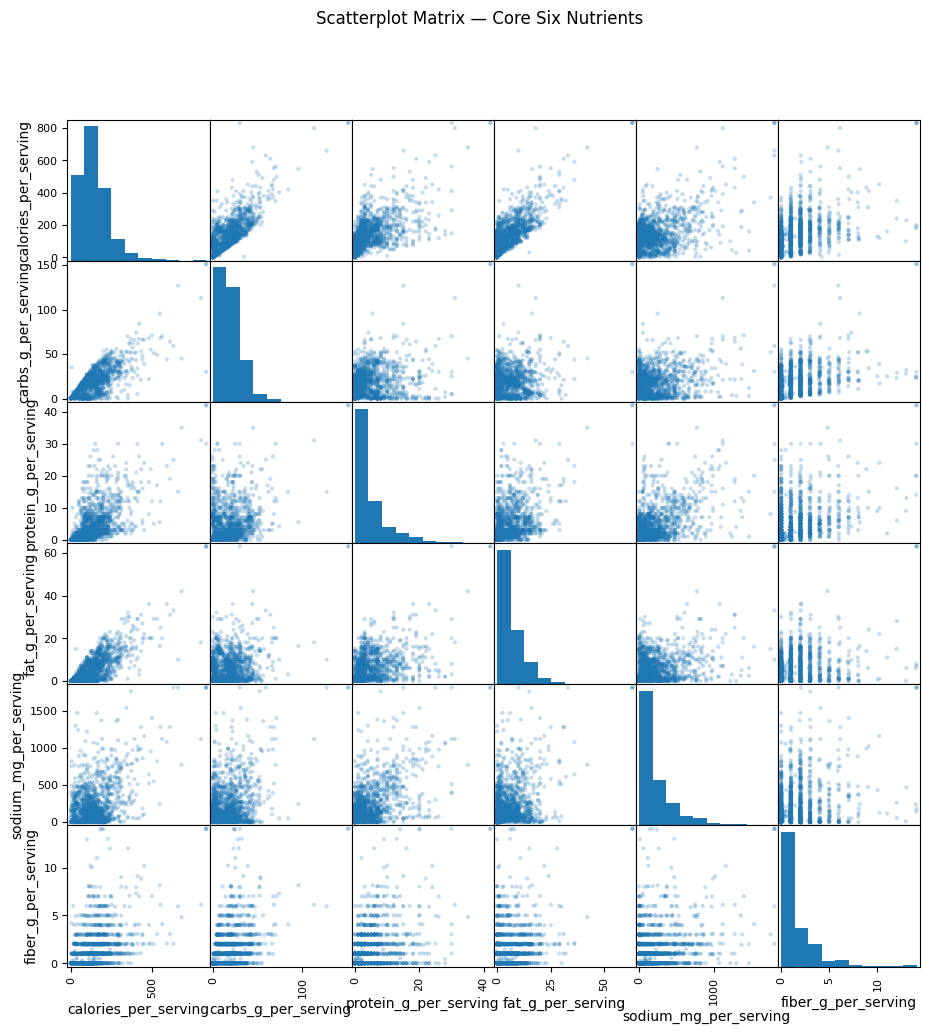

In [25]:

CORE_SIX = ["calories_per_serving","carbs_g_per_serving","protein_g_per_serving",
            "fat_g_per_serving","sodium_mg_per_serving","fiber_g_per_serving"]
use_for_matrix = [c for c in CORE_SIX if c in df_w.columns]

df_for_matrix = df_w[use_for_matrix].dropna()

# Sample to reduce overplotting if very large
MAX_SMPL = 1500
if len(df_for_matrix) > MAX_SMPL:
    df_for_matrix = df_for_matrix.sample(MAX_SMPL, random_state=42)

axarr = scatter_matrix(df_for_matrix, figsize=(11, 11), diagonal='hist', alpha=0.25)
plt.suptitle("Scatterplot Matrix — Core Six Nutrients")
plt.show()
